In [ ]:
import pandas as pd

data = pd.read_csv('HR_comma_sep.csv')

data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# 1. Describe the data in a table (shows basic statistics like mean, min, and max)
print("--- Data Description ---")
display(data.describe())

# 2. Show a sample of the data (random 10 samples)
print("\n--- Random 10 Samples ---")
display(data.sample(10))

--- Data Description ---


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000



--- Random 10 Samples ---


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
12298,0.45,0.48,2,136,3,0,1,0,product_mng,medium
1996,0.11,0.92,7,293,4,0,1,0,sales,low
5860,0.90,0.62,5,236,6,0,0,0,technical,medium
6755,0.99,0.92,3,154,3,0,0,0,technical,medium
10259,0.79,0.98,4,170,3,0,0,0,hr,low
13,0.41,0.55,2,148,3,0,1,0,sales,low
4862,0.73,0.79,4,157,3,0,0,0,support,medium
6153,0.65,0.60,3,142,2,0,0,0,support,high
8013,0.86,0.53,4,155,3,0,0,0,marketing,high
4447,0.71,0.92,4,248,3,1,0,0,sales,low


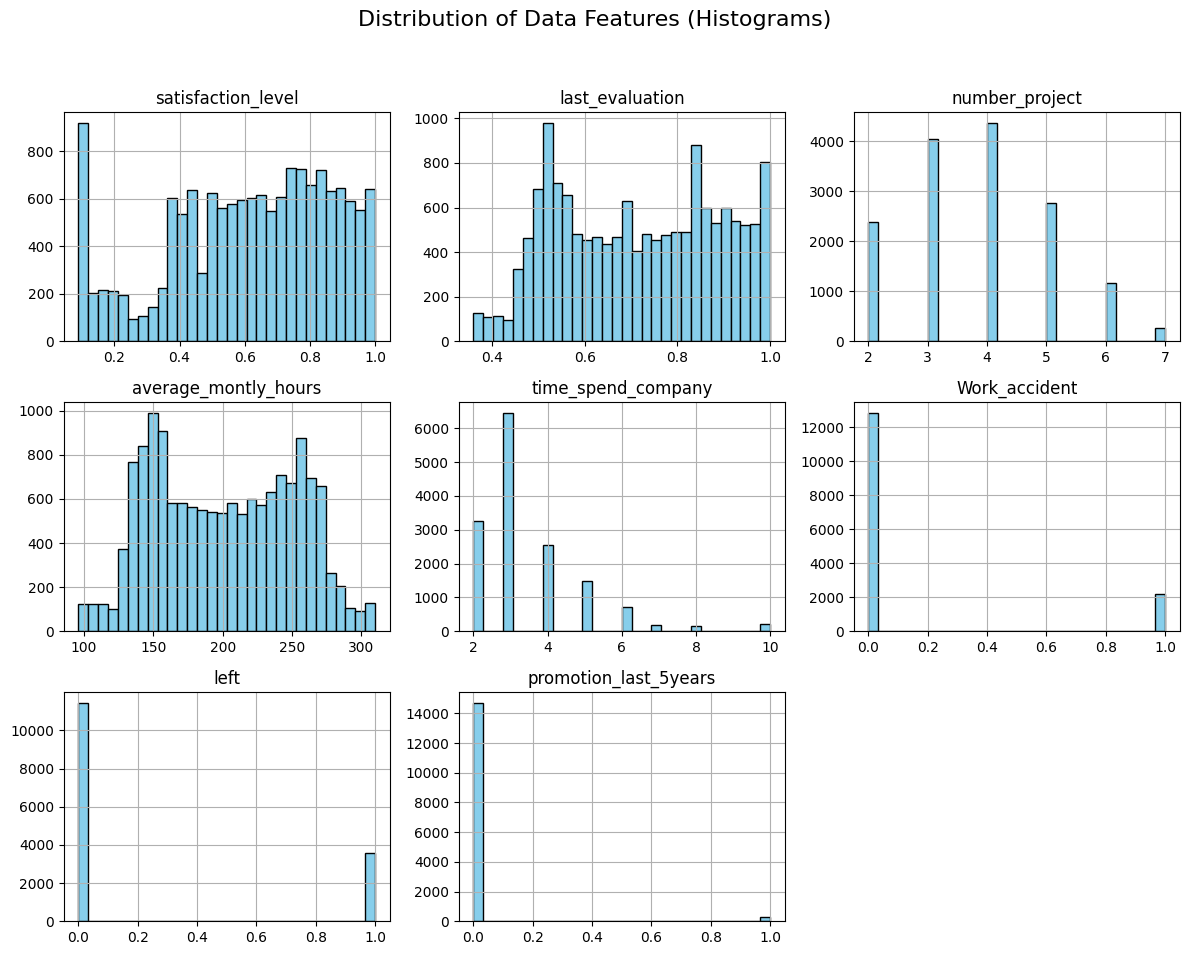

In [4]:
import matplotlib.pyplot as plt

# Show the distribution of the features using histograms
data.hist(figsize=(12, 10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Data Features (Histograms)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Bivariate Analysis: All Features vs 'left' (9-Panel Grid) ---


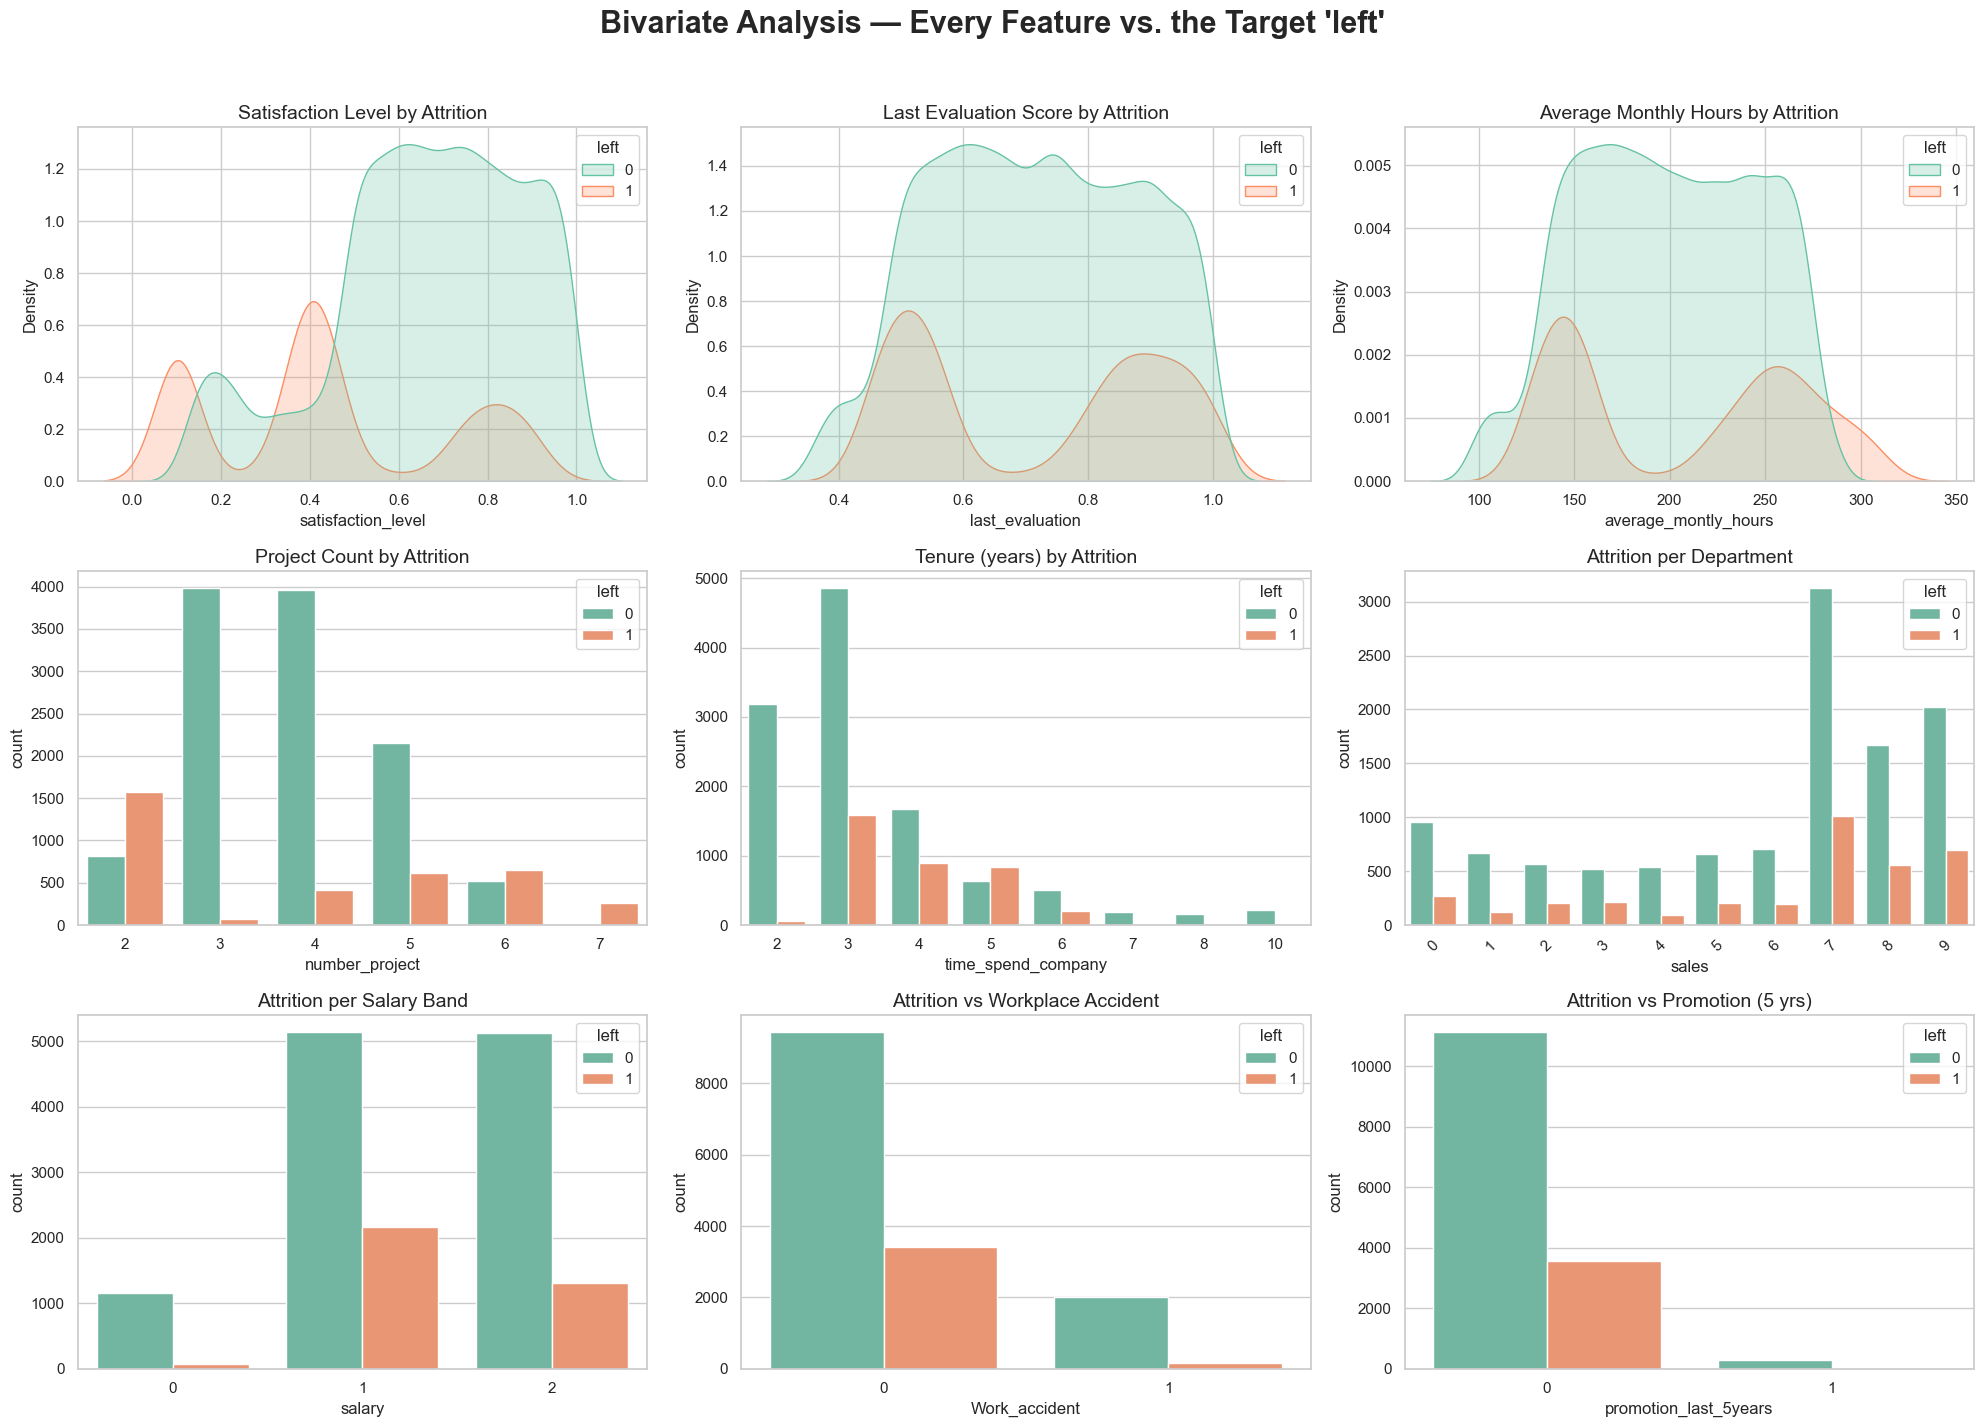

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Bivariate Analysis: All Features vs 'left' (9-Panel Grid) ---")

# Set the style to look professional
sns.set_theme(style="whitegrid")

# Create a figure with 3x3 subplots (width=20, height=15)
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Bivariate Analysis — Every Feature vs. the Target 'left'", fontsize=22, weight='bold')

# Row 1: Continuous Data (Using KDE plots for smooth curves)
sns.kdeplot(data=data, x='satisfaction_level', hue='left', fill=True, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Satisfaction Level by Attrition', fontsize=14)

sns.kdeplot(data=data, x='last_evaluation', hue='left', fill=True, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Last Evaluation Score by Attrition', fontsize=14)

sns.kdeplot(data=data, x='average_montly_hours', hue='left', fill=True, palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('Average Monthly Hours by Attrition', fontsize=14)

# Row 2: Categorical Data (Using Count plots for bars)
sns.countplot(data=data, x='number_project', hue='left', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Project Count by Attrition', fontsize=14)

sns.countplot(data=data, x='time_spend_company', hue='left', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Tenure (years) by Attrition', fontsize=14)

sns.countplot(data=data, x='sales', hue='left', palette='Set2', ax=axes[1, 2])
axes[1, 2].set_title('Attrition per Department', fontsize=14)
axes[1, 2].tick_params(axis='x', rotation=45) # Rotate text for better fit

# Row 3: More Categorical Data
sns.countplot(data=data, x='salary', hue='left', palette='Set2', ax=axes[2, 0])
axes[2, 0].set_title('Attrition per Salary Band', fontsize=14)

sns.countplot(data=data, x='Work_accident', hue='left', palette='Set2', ax=axes[2, 1])
axes[2, 1].set_title('Attrition vs Workplace Accident', fontsize=14)

sns.countplot(data=data, x='promotion_last_5years', hue='left', palette='Set2', ax=axes[2, 2])
axes[2, 2].set_title('Attrition vs Promotion (5 yrs)', fontsize=14)

# Adjust layout so titles and labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

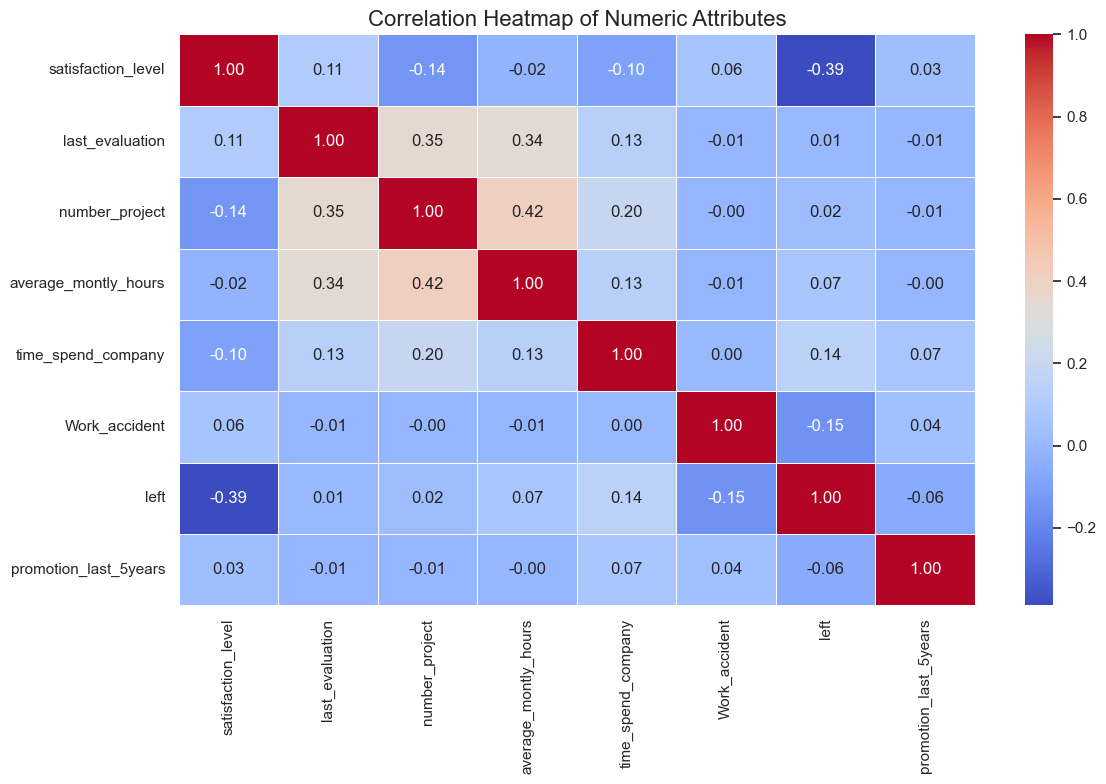

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numeric columns for the correlation matrix (text cannot be correlated mathematically)
numeric_columns = data.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Attributes", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

print("--- Pre-processing: Encoding Categorical Data ---")

# Create a LabelEncoder object
encoder = LabelEncoder()

# Find columns that have text data (object/string type)
categorical_columns = data.select_dtypes(include=['object']).columns

# Convert text in these columns to numbers
for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])
    print(f"Encoded column: '{col}'")

# Show the first 5 rows to verify the changes
print("\n--- Data After Encoding ---")
display(data.head())

--- Pre-processing: Encoding Categorical Data ---
Encoded column: 'sales'
Encoded column: 'salary'

--- Data After Encoding ---


C:\Users\Admin\AppData\Local\Temp\ipykernel_28352\4035680884.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=['object']).columns


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
1,0.80,0.86,5,262,6,0,1,0,7,2
2,0.11,0.88,7,272,4,0,1,0,7,2
3,0.72,0.87,5,223,5,0,1,0,7,1
4,0.37,0.52,2,159,3,0,1,0,7,1


--- Clustering Analysis for Employees Who Left ---


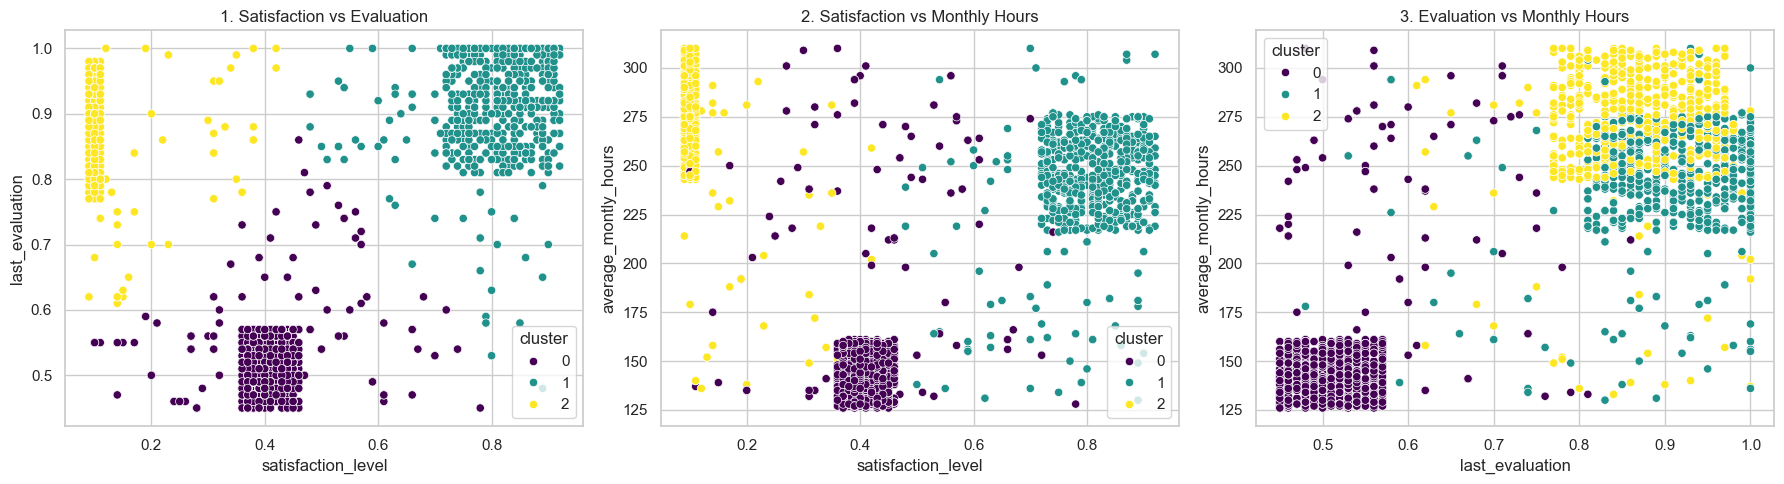

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Clustering Analysis for Employees Who Left ---")

# 1. Filter data: focus ONLY on employees who left (left == 1)
left_emp = data[data['left'] == 1].copy()

# 2. Select the most important features to cluster them
cluster_features = left_emp[['satisfaction_level', 'last_evaluation']]

# 3. Apply K-Means clustering (grouping them into 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
left_emp['cluster'] = kmeans.fit_predict(cluster_features)

# 4. Plot the 3 requested clustering diagrams
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Diagram 1: Satisfaction vs Evaluation
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', data=left_emp, palette='viridis', ax=axes[0])
axes[0].set_title('1. Satisfaction vs Evaluation')

# Diagram 2: Satisfaction vs Monthly Hours
sns.scatterplot(x='satisfaction_level', y='average_montly_hours', hue='cluster', data=left_emp, palette='viridis', ax=axes[1])
axes[1].set_title('2. Satisfaction vs Monthly Hours')

# Diagram 3: Evaluation vs Monthly Hours
sns.scatterplot(x='last_evaluation', y='average_montly_hours', hue='cluster', data=left_emp, palette='viridis', ax=axes[2])
axes[2].set_title('3. Evaluation vs Monthly Hours')

plt.tight_layout()
plt.show()

--- Building Models and Evaluation ---

1. MLP Back Propagation Model Results:
Accuracy:  0.9257
Precision: 0.8313
Recall:    0.8584
F-Score:   0.8446


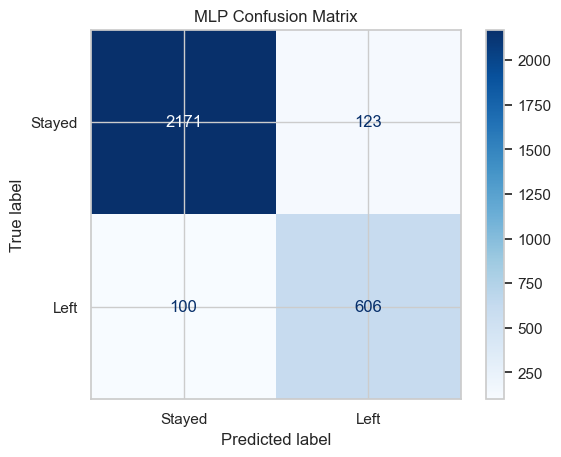


2. Gradient Boosting Classifier Results:
Accuracy:  0.9737
Precision: 0.9617
Recall:    0.9249
F-Score:   0.9430


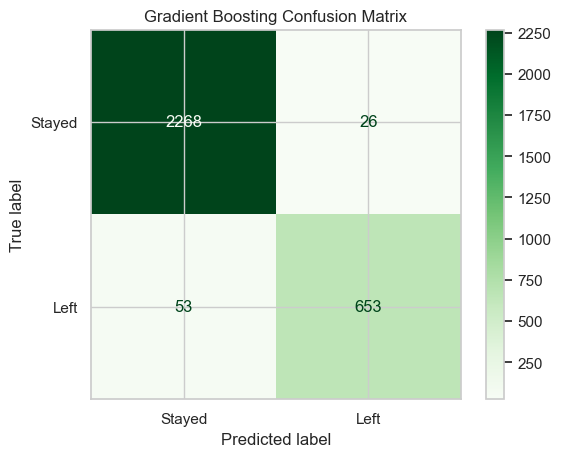

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Building Models and Evaluation ---")

# 1. Define Features (X) and Target (y)
X = data.drop('left', axis=1) # All columns except 'left'
y = data['left'] # The target column

# 2. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Model 1: MLP Back Propagation (Neural Network)
# ==========================================
print("\n1. MLP Back Propagation Model Results:")
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)
mlp_predictions = mlp_model.predict(X_test)

# Calculate metrics for MLP
print(f"Accuracy:  {accuracy_score(y_test, mlp_predictions):.4f}")
print(f"Precision: {precision_score(y_test, mlp_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, mlp_predictions):.4f}")
print(f"F-Score:   {f1_score(y_test, mlp_predictions):.4f}")

# Plot Confusion Matrix for MLP
disp_mlp = ConfusionMatrixDisplay(confusion_matrix(y_test, mlp_predictions), display_labels=['Stayed', 'Left'])
disp_mlp.plot(cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.show()

# ==========================================
# Model 2: Gradient Boosting Classifier
# ==========================================
print("\n2. Gradient Boosting Classifier Results:")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

# Calculate metrics for Gradient Boosting
print(f"Accuracy:  {accuracy_score(y_test, gb_predictions):.4f}")
print(f"Precision: {precision_score(y_test, gb_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, gb_predictions):.4f}")
print(f"F-Score:   {f1_score(y_test, gb_predictions):.4f}")

# Plot Confusion Matrix for Gradient Boosting
disp_gb = ConfusionMatrixDisplay(confusion_matrix(y_test, gb_predictions), display_labels=['Stayed', 'Left'])
disp_gb.plot(cmap='Greens')
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [10]:
print(f"Number of employees for training: {len(X_train)}")
print(f"Number of employees for testing: {len(X_test)}")

Number of employees for training: 11999
Number of employees for testing: 3000
